# 경복궁 일별 방문객 예측

- 입력 데이터: `../data/preprocessed/eda_gbg_master.csv`
- 주된 흐름: `baseline` -> `ktci` -> `ktci-a` -> `ktci-a-roll7`
- 핵심 가설
  - `baseline`: ASOS 기온만 쓰는 것보다 `ktci`가 더 좋을 것이다
  - `ktci`: 한국형 관광기후지수는 더 강한 외생변수일 것이다
  - `ktci-a`: 계절을 다시 계산하면 한국의 계절 전환을 더 잘 반영할 것이다
  - `ktci-a-roll7`: 보간과 7일 평활화를 적용하면 더 안정적일 것이다
- Methodology
  - `5.1` 정상성 검정: 시계열 그래프, ADF, KPSS, ACF, PACF
  - `5.2` SARIMAX: baseline(ASOS), KTCI, KTCI-a, KTCI-a-roll7
  - `5.3` Granger test: 과거 외생변수가 미래 방문객 수에 선행 정보를 주는지 확인
- 포함 내용: 정상성 검정, Granger 선별, SARIMAX 적합, 잔차 점검, 예측 그래프, 계수 비교


In [111]:
# ============================================================
# 0. 라이브러리 및 설정
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "modeling" else Path.cwd()
MASTER_PATH = PROJECT_ROOT / "data" / "preprocessed" / "eda_gbg_master.csv"

if not MASTER_PATH.exists():
    raise FileNotFoundError(f"필수 입력 파일이 없습니다: {MASTER_PATH}")

TARGET_COL = "visitors"
SCALAR_MAIN_VARS = [
    "tavg",
    "ktci",
    "ktci_a",
    "ktci_a_roll7",
]
COVID_COMPARE_COLS = ["covid_v1", "covid_v2", "covid_v3"]
DEFAULT_COVID_COL = "covid_v3"
RAW_CONTROL_COLS = [
    "rain",
    "pm10",
    DEFAULT_COVID_COL,
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
]
DERIVED_HOLIDAY_COLS = [
    "offdays_left",
    "long_break_3p",
    "pre_holiday",
]
BASE_CONTROL_COLS = [
    *RAW_CONTROL_COLS,
    *DERIVED_HOLIDAY_COLS,
]
COMMON_INTERACTION_COLS = [
    "rain_c_x_weekend",
    "rain_c_x_offdays_left",
]
MAIN_VARIABLES = {
    "Baseline (Temperature)": "tavg",
    "KTCI Model": "ktci",
    "KTCI-a Model": "ktci_a",
    "KTCI-a-roll7 Model": "ktci_a_roll7",
}

SARIMAX_ORDER = (2, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 7)
MAXITER = 200
TEST_SIZE = 365

def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot


In [112]:
# ============================================================
# 1. 데이터 로드
# ============================================================
master = pd.read_csv(MASTER_PATH, encoding="utf-8-sig")
master["date"] = pd.to_datetime(master["date"])

print("master shape:", master.shape)
display(master.head())


master shape: (6209, 94)


,date,year,month,day,dow,dow_name,is_weekend,is_regular_closed_tuesday,closed,others_closed,...,Ca,P,W,S,pm10,wind_speed,humidity,solar_rad,event_day,covid_stage
0,2009-01-01,2009,1,1,3,목,0,0,0,0,...,1.5,5.0,4.0,4.40,43.000,2.3,45.8,9.49,0,non_covid_period
1,2009-01-02,2009,1,2,4,금,0,0,0,0,...,1.5,5.0,4.5,4.40,52.250,1.6,51.5,8.87,0,non_covid_period
2,2009-01-03,2009,1,3,5,토,1,0,0,0,...,2.0,5.0,4.0,4.40,56.750,1.8,48.3,8.73,0,non_covid_period
3,2009-01-04,2009,1,4,6,일,1,0,0,0,...,2.0,5.0,4.0,4.20,42.875,1.9,44.3,9.02,0,non_covid_period
4,2009-01-05,2009,1,5,0,월,0,0,0,2,...,2.0,5.0,4.0,2.45,62.750,2.2,53.1,6.32,0,non_covid_period


In [113]:
# ============================================================
# 2. 날짜 정리
# ============================================================
df = master.copy()
df = df.set_index("date").sort_index().asfreq("D")

print("df shape:", df.shape)
print("period:", df.index.min(), "~", df.index.max())
for col in ["tavg", "ktci", "ktci_a", "ktci_a_roll7", "pm10", "closed", "others_closed", "d_holiday"]:
    print(f"{col} missing:", df[col].isna().sum())

display(df[["visitors", "tavg", "ktci", "ktci_a", "ktci_a_roll7", "pm10", "closed", "others_closed", "d_holiday"]].head())


df shape: (6209, 93)
period: 2009-01-01 00:00:00 ~ 2025-12-31 00:00:00
tavg missing: 0
ktci missing: 0
ktci_a missing: 0
ktci_a_roll7 missing: 0
pm10 missing: 283
closed missing: 0
others_closed missing: 0
d_holiday missing: 0


,visitors,tavg,ktci,ktci_a,ktci_a_roll7,pm10,closed,others_closed,d_holiday
date,,,,,,,,,
2009-01-01,9966,-5.8,65.76,65.76,65.76,43.000,0,0,1
2009-01-02,7871,-2.8,67.22,67.22,66.49,52.250,0,0,0
2009-01-03,10553,-1.0,70.42,70.42,67.80,56.750,0,0,0
2009-01-04,7928,0.4,70.09,70.09,68.37,42.875,0,0,0
2009-01-05,5056,-1.6,64.99,64.99,67.70,62.750,0,2,0


In [114]:
# ============================================================
# 3. 모델링 데이터 정리 + 연휴/상호작용 변수 생성
# ============================================================
required_cols = [
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    "season_month",
    "season_temp",
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")

model_df = df[[
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    "season_month",
    "season_temp",
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
]].copy()

numeric_cols = [
    TARGET_COL,
    *SCALAR_MAIN_VARS,
    "rain",
    "pm10",
    "closed",
    "others_closed",
    "is_weekend",
    "d_holiday",
    *COVID_COMPARE_COLS,
]
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# 기상/쾌적도 계열은 시간축 기준 보간
interpolate_cols = [*SCALAR_MAIN_VARS[1:], "pm10"]
for col in interpolate_cols:
    model_df[col] = model_df[col].interpolate(method="time").ffill().bfill()

# 휴일/운영 더미는 결측이 있으면 0으로 처리
fill_zero_cols = ["rain", "closed", "others_closed", "is_weekend", "d_holiday", *COVID_COMPARE_COLS]
for col in fill_zero_cols:
    model_df[col] = model_df[col].fillna(0)

model_df = model_df.sort_index()

remaining_missing = model_df[numeric_cols].isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    raise ValueError(f"전처리 후에도 결측이 남아 있습니다: {remaining_missing.to_dict()}")

model_df["offday"] = ((model_df["is_weekend"] == 1) | (model_df["d_holiday"] == 1)).astype(int)
model_df["next_day_off"] = model_df["offday"].shift(-1, fill_value=0).astype(int)
model_df["pre_holiday"] = ((model_df["offday"] == 0) & (model_df["next_day_off"] == 1)).astype(int)

offday_group = model_df["offday"].ne(model_df["offday"].shift(fill_value=0)).cumsum()
offday_block_total = model_df.groupby(offday_group)["offday"].transform("sum")
offday_position = model_df.groupby(offday_group).cumcount() + 1
model_df["offdays_left"] = np.where(
    model_df["offday"] == 1,
    offday_block_total - offday_position + 1,
    0,
).astype(int)
model_df["long_break_3p"] = ((model_df["offday"] == 1) & (offday_block_total >= 3)).astype(int)

# 상호작용 공선성 완화를 위해 연속형 변수는 평균중심화 후 interaction 생성
for col in ["rain", *SCALAR_MAIN_VARS]:
    model_df[f"{col}_c"] = model_df[col] - model_df[col].mean()

model_df["rain_c_x_weekend"] = model_df["rain_c"] * model_df["is_weekend"]
model_df["rain_c_x_offdays_left"] = model_df["rain_c"] * model_df["offdays_left"]

for main_var in SCALAR_MAIN_VARS:
    model_df[f"{main_var}_c_x_weekend"] = model_df[f"{main_var}_c"] * model_df["is_weekend"]
    model_df[f"{main_var}_c_x_offdays_left"] = model_df[f"{main_var}_c"] * model_df["offdays_left"]

if len(model_df) <= TEST_SIZE:
    raise ValueError(f"TEST_SIZE={TEST_SIZE}가 데이터 길이보다 큽니다.")

train_df = model_df.iloc[:-TEST_SIZE].copy()
test_df = model_df.iloc[-TEST_SIZE:].copy()

print("model_df shape:", model_df.shape)
print("train period:", train_df.index.min(), "~", train_df.index.max(), f"({len(train_df)} rows)")
print("test period:", test_df.index.min(), "~", test_df.index.max(), f"({len(test_df)} rows)")
print("days with next day off:", int(model_df["next_day_off"].sum()))
print("days in 3+ day breaks:", int(model_df["long_break_3p"].sum()))
print("days before holiday blocks:", int(model_df["pre_holiday"].sum()))
print("pm10 interpolated days:", int(df["pm10"].isna().sum()))

display(model_df[[TARGET_COL, *SCALAR_MAIN_VARS, "next_day_off", "offdays_left", "long_break_3p", "pre_holiday"]].head(10))


model_df shape: (6209, 36)
train period: 2009-01-01 00:00:00 ~ 2024-12-31 00:00:00 (5844 rows)
test period: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00 (365 rows)
days with next day off: 1985
days in 3+ day breaks: 312
days before holiday blocks: 956
pm10 interpolated days: 283


,visitors,tavg,ktci,ktci_a,ktci_a_roll7,next_day_off,offdays_left,long_break_3p,pre_holiday
date,,,,,,,,,
2009-01-01,9966,-5.8,65.76,65.76,65.76,0,1,0,0
2009-01-02,7871,-2.8,67.22,67.22,66.49,1,0,0,1
2009-01-03,10553,-1.0,70.42,70.42,67.80,1,2,0,0
2009-01-04,7928,0.4,70.09,70.09,68.37,0,1,0,0
2009-01-05,5056,-1.6,64.99,64.99,67.70,0,0,0,0
2009-01-06,0,-2.0,65.07,65.07,67.26,0,0,0,0
2009-01-07,4571,-0.5,70.26,70.26,67.69,0,0,0,0
2009-01-08,3567,-0.9,68.31,68.31,68.05,0,0,0,0
2009-01-09,3456,-3.5,62.76,62.76,67.41,1,0,0,1


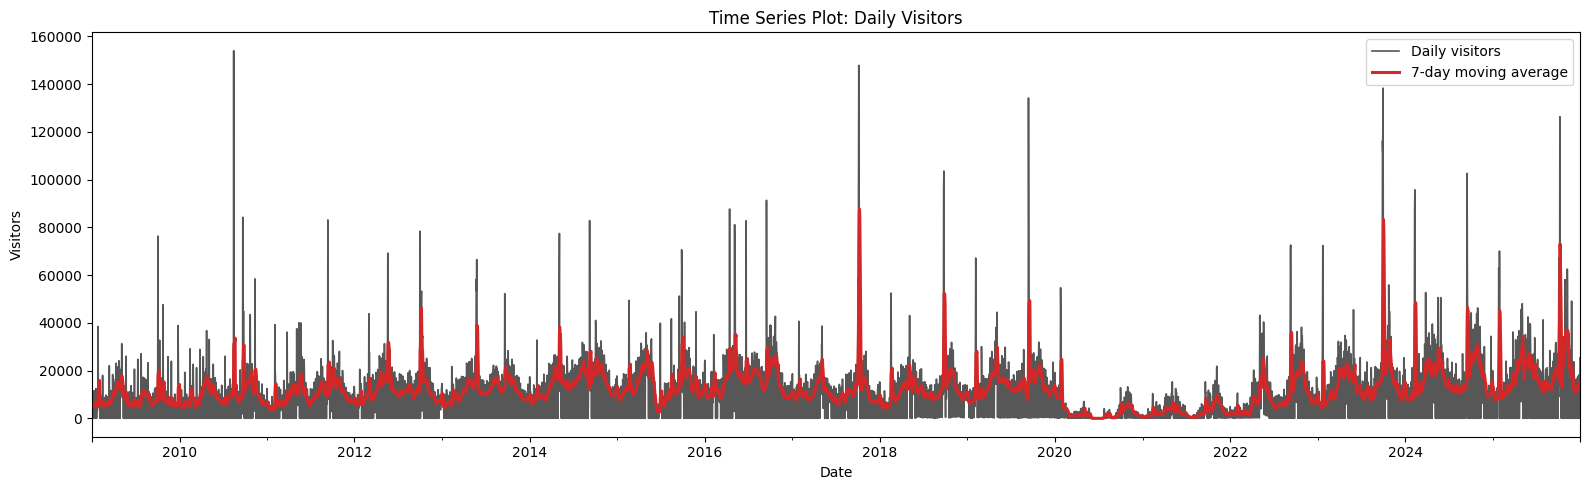

In [115]:
# ============================================================
# 5.1 시계열 그래프: 방문객 수의 장기 추세와 변동성 확인
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))
model_df[TARGET_COL].plot(ax=ax, color="#1f1f1f", linewidth=1.2, alpha=0.75, label="Daily visitors")
model_df[TARGET_COL].rolling(7).mean().plot(ax=ax, color="#d62728", linewidth=2.2, label="7-day moving average")
ax.set_title("Time Series Plot: Daily Visitors")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


,series,ADF Statistic,ADF p-value,ADF usedlag,ADF nobs,ADF 1%,ADF 5%,ADF 10%,KPSS Statistic,KPSS p-value,KPSS lags,KPSS 10%,KPSS 5%,KPSS 2.5%,KPSS 1%
0,visitors,-6.3327,0.0,34,6174,-3.4314,-2.862,-2.567,0.7757,0.01,37,0.347,0.463,0.574,0.739
1,tavg,-6.0868,0.0,34,6174,-3.4314,-2.862,-2.567,0.0825,0.10,45,0.347,0.463,0.574,0.739
2,ktci,-7.0461,0.0,17,6191,-3.4314,-2.862,-2.567,0.1186,0.10,42,0.347,0.463,0.574,0.739
3,ktci_a,-7.0653,0.0,17,6191,-3.4314,-2.862,-2.567,0.1201,0.10,42,0.347,0.463,0.574,0.739
4,ktci_a_roll7,-7.6628,0.0,33,6175,-3.4314,-2.862,-2.567,0.1197,0.10,44,0.347,0.463,0.574,0.739


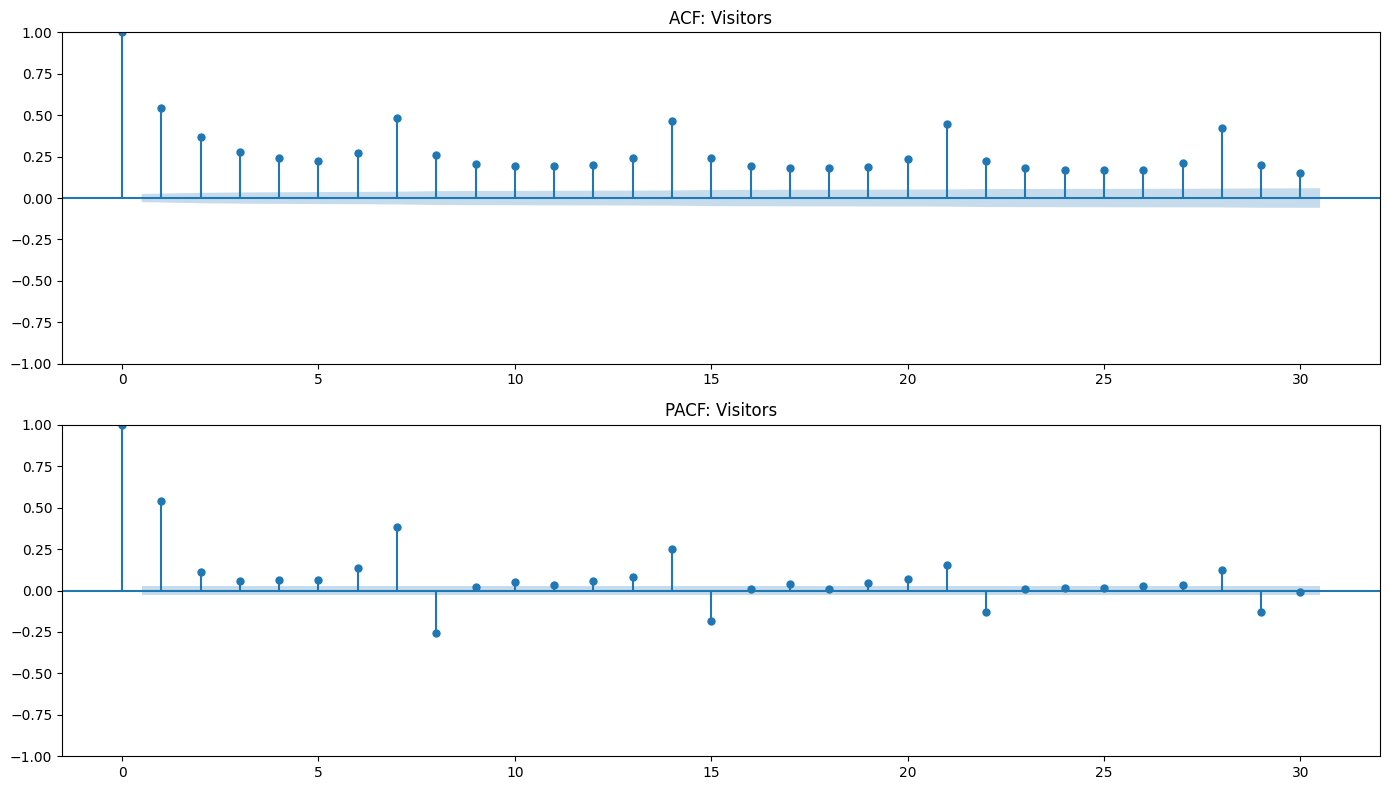

In [116]:
# ============================================================
# 5.1 정상성 검정: ADF 검정 + KPSS 검정 + 기본 ACF/PACF
# ============================================================
def run_adf_test(series, name):
    test_series = series.dropna()
    stat, p_value, usedlag, nobs, critical_values, _ = adfuller(test_series, autolag="AIC")
    return {
        "series": name,
        "ADF Statistic": stat,
        "ADF p-value": p_value,
        "ADF usedlag": usedlag,
        "ADF nobs": nobs,
        "ADF 1%": critical_values["1%"],
        "ADF 5%": critical_values["5%"],
        "ADF 10%": critical_values["10%"],
    }

def run_kpss_test(series, name):
    test_series = series.dropna()
    stat, p_value, lags, critical_values = kpss(test_series, regression="c", nlags="auto")
    return {
        "series": name,
        "KPSS Statistic": stat,
        "KPSS p-value": p_value,
        "KPSS lags": lags,
        "KPSS 10%": critical_values["10%"],
        "KPSS 5%": critical_values["5%"],
        "KPSS 2.5%": critical_values["2.5%"],
        "KPSS 1%": critical_values["1%"],
    }

stationarity_targets = {name: model_df[name] for name in [TARGET_COL, *SCALAR_MAIN_VARS]}
adf_df = pd.DataFrame([run_adf_test(series, name) for name, series in stationarity_targets.items()])
kpss_df = pd.DataFrame([run_kpss_test(series, name) for name, series in stationarity_targets.items()])
stationarity_df = adf_df.merge(kpss_df, on="series")
display(stationarity_df.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(model_df[TARGET_COL], ax=axes[0], lags=30, title="ACF: Visitors")
plot_pacf(model_df[TARGET_COL], ax=axes[1], lags=30, title="PACF: Visitors", method="ywm")
plt.tight_layout()
plt.show()


,series,ADF Statistic,ADF p-value,ADF usedlag,ADF nobs,ADF 1%,ADF 5%,ADF 10%,KPSS Statistic,KPSS p-value,KPSS lags,KPSS 10%,KPSS 5%,KPSS 2.5%,KPSS 1%
0,visitors,-6.3327,0.0,34,6174,-3.4314,-2.862,-2.567,0.7757,0.01,37,0.347,0.463,0.574,0.739
1,tavg,-6.0868,0.0,34,6174,-3.4314,-2.862,-2.567,0.0825,0.10,45,0.347,0.463,0.574,0.739
2,ktci,-7.0461,0.0,17,6191,-3.4314,-2.862,-2.567,0.1186,0.10,42,0.347,0.463,0.574,0.739
3,ktci_a,-7.0653,0.0,17,6191,-3.4314,-2.862,-2.567,0.1201,0.10,42,0.347,0.463,0.574,0.739
4,ktci_a_roll7,-7.6628,0.0,33,6175,-3.4314,-2.862,-2.567,0.1197,0.10,44,0.347,0.463,0.574,0.739


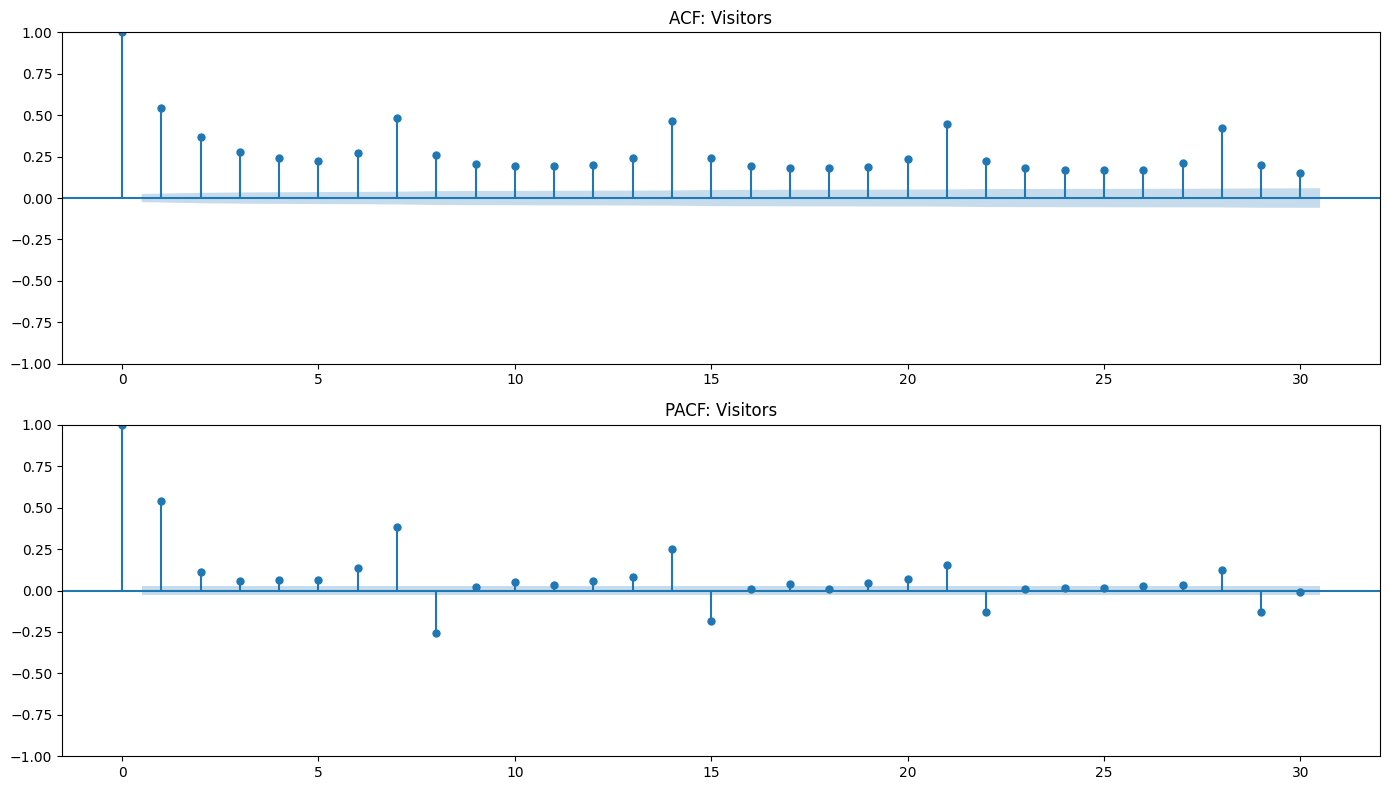

In [117]:
# ============================================================
# 5.1 정상성 검정: ADF 검정 + KPSS 검정 + 기본 ACF/PACF
# ============================================================
def run_adf_test(series, name):
    test_series = series.dropna()
    stat, p_value, usedlag, nobs, critical_values, _ = adfuller(test_series, autolag="AIC")
    return {
        "series": name,
        "ADF Statistic": stat,
        "ADF p-value": p_value,
        "ADF usedlag": usedlag,
        "ADF nobs": nobs,
        "ADF 1%": critical_values["1%"],
        "ADF 5%": critical_values["5%"],
        "ADF 10%": critical_values["10%"],
    }

def run_kpss_test(series, name):
    test_series = series.dropna()
    stat, p_value, lags, critical_values = kpss(test_series, regression="c", nlags="auto")
    return {
        "series": name,
        "KPSS Statistic": stat,
        "KPSS p-value": p_value,
        "KPSS lags": lags,
        "KPSS 10%": critical_values["10%"],
        "KPSS 5%": critical_values["5%"],
        "KPSS 2.5%": critical_values["2.5%"],
        "KPSS 1%": critical_values["1%"],
    }

stationarity_targets = {name: model_df[name] for name in [TARGET_COL, *SCALAR_MAIN_VARS]}
adf_df = pd.DataFrame([run_adf_test(series, name) for name, series in stationarity_targets.items()])
kpss_df = pd.DataFrame([run_kpss_test(series, name) for name, series in stationarity_targets.items()])
stationarity_df = adf_df.merge(kpss_df, on="series")
display(stationarity_df.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(model_df[TARGET_COL], ax=axes[0], lags=30, title="ACF: Visitors")
plot_pacf(model_df[TARGET_COL], ax=axes[1], lags=30, title="PACF: Visitors", method="ywm")
plt.tight_layout()
plt.show()


In [118]:
# ============================================================
# 6. 평가 / 적합 함수
# ============================================================
def build_control_cols(covid_col=DEFAULT_COVID_COL):
    return [
        "rain",
        "pm10",
        covid_col,
        "closed",
        "others_closed",
        "is_weekend",
        "d_holiday",
        *DERIVED_HOLIDAY_COLS,
    ]

def build_exog_columns(main_var, covid_col=DEFAULT_COVID_COL):
    return [
        main_var,
        *build_control_cols(covid_col),
        *COMMON_INTERACTION_COLS,
        f"{main_var}_c_x_weekend",
        f"{main_var}_c_x_offdays_left",
    ]

def main_variable_label(main_var):
    if isinstance(main_var, list):
        return ", ".join(main_var)
    return main_var

def adjusted_r2_score(y_true, y_pred, n_predictors):
    n_obs = len(y_true)
    r2 = r2_score(y_true, y_pred)
    if n_obs <= n_predictors + 1:
        return np.nan
    return 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_predictors - 1)

def evaluate_forecast(y_true, y_pred, n_predictors):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": adjusted_r2_score(y_true, y_pred, n_predictors),
    }

def fit_sarimax_model(model_name, main_var, train_df, test_df, covid_col=DEFAULT_COVID_COL):
    exog_cols = build_exog_columns(main_var, covid_col=covid_col)
    y_train = train_df[TARGET_COL]
    y_test = test_df[TARGET_COL]
    X_train = train_df[exog_cols]
    X_test = test_df[exog_cols]

    model = SARIMAX(
        y_train,
        exog=X_train,
        order=SARIMAX_ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False, maxiter=MAXITER)

    pred = result.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
    pred = pd.Series(pred, index=y_test.index, name=model_name)

    metrics = evaluate_forecast(y_test, pred, len(exog_cols))
    score = {
        "model": model_name,
        "main_variable": main_variable_label(main_var),
        "n_predictors": len(exog_cols),
        "AIC": result.aic,
        "BIC": result.bic,
        **metrics,
    }
    return result, pred, score, exog_cols

vif_tables = {}
for model_name, main_var in MAIN_VARIABLES.items():
    exog_cols = build_exog_columns(main_var)
    vif_df, zero_variance_cols = compute_vif_table(train_df, exog_cols)
    vif_tables[model_name] = vif_df

    print(f"=== {model_name} ===")
    print(f"main variable : {main_var}")
    print(f"n predictors  : {len(exog_cols)}")
    print(f"zero variance : {zero_variance_cols}")
    print()
    display(vif_df.head(15))


=== Baseline (Temperature) ===
main variable : tavg
n predictors  : 15
zero variance : []



,variable,VIF
8,offdays_left,6.207809
6,is_weekend,4.966718
13,tavg_c_x_weekend,3.633408
14,tavg_c_x_offdays_left,3.547121
0,tavg,2.542984
2,pm10,2.097774
9,long_break_3p,2.047572
12,rain_c_x_offdays_left,2.001077
11,rain_c_x_weekend,1.932250
7,d_holiday,1.850675


=== KTCI Model ===
main variable : ktci
n predictors  : 15
zero variance : []



,variable,VIF
8,offdays_left,6.399928
6,is_weekend,5.315045
0,ktci,5.202234
13,ktci_c_x_weekend,3.892854
14,ktci_c_x_offdays_left,3.800389
2,pm10,3.136531
11,rain_c_x_weekend,2.284649
12,rain_c_x_offdays_left,2.232294
9,long_break_3p,2.048768
7,d_holiday,1.868176


=== KTCI-a Model ===
main variable : ktci_a
n predictors  : 15
zero variance : []



,variable,VIF
8,offdays_left,6.371113
6,is_weekend,5.298535
0,ktci_a,5.205134
13,ktci_a_c_x_weekend,3.910662
14,ktci_a_c_x_offdays_left,3.797407
2,pm10,3.137933
11,rain_c_x_weekend,2.273925
12,rain_c_x_offdays_left,2.210377
9,long_break_3p,2.048773
7,d_holiday,1.867231


=== KTCI-a-roll7 Model ===
main variable : ktci_a_roll7
n predictors  : 15
zero variance : []



,variable,VIF
8,offdays_left,6.420170
0,ktci_a_roll7,5.342342
6,is_weekend,5.328732
2,pm10,3.131272
14,ktci_a_roll7_c_x_offdays_left,3.039737
13,ktci_a_roll7_c_x_weekend,2.973699
9,long_break_3p,2.049125
12,rain_c_x_offdays_left,1.975488
11,rain_c_x_weekend,1.884016
7,d_holiday,1.872775


In [119]:
# ============================================================
# 7. 다중공선성(VIF) 점검
# ============================================================
def compute_vif_table(frame, exog_cols):
    X = frame[exog_cols].copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    zero_variance_cols = [col for col in X.columns if X[col].nunique() <= 1]
    X = X.drop(columns=zero_variance_cols)

    if X.empty:
        return pd.DataFrame(columns=["variable", "VIF"]), zero_variance_cols

    vif_rows = []
    for i, column in enumerate(X.columns):
        try:
            vif_value = variance_inflation_factor(X.values, i)
        except Exception:
            vif_value = np.nan
        vif_rows.append({"variable": column, "VIF": vif_value})

    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    return vif_df, zero_variance_cols


vif_tables = {}
for model_name, main_var in MAIN_VARIABLES.items():
    exog_cols = build_exog_columns(main_var, )
    vif_df, zero_variance_cols = compute_vif_table(train_df, exog_cols)
    vif_tables[model_name] = vif_df

    print(f"=== {model_name} ===")
    if zero_variance_cols:
        print("zero variance columns:", zero_variance_cols)

    display(vif_df.head(15))

    high_vif = vif_df[vif_df["VIF"] >= 10]
    if not high_vif.empty:
        print("warning: VIF >= 10")
        display(high_vif)
    elif not vif_df.empty:
        print("VIF >= 10 인 변수는 없습니다.")
    print()


=== Baseline (Temperature) ===


,variable,VIF
8,offdays_left,6.207809
6,is_weekend,4.966718
13,tavg_c_x_weekend,3.633408
14,tavg_c_x_offdays_left,3.547121
0,tavg,2.542984
2,pm10,2.097774
9,long_break_3p,2.047572
12,rain_c_x_offdays_left,2.001077
11,rain_c_x_weekend,1.932250
7,d_holiday,1.850675


VIF >= 10 인 변수는 없습니다.

=== KTCI Model ===


,variable,VIF
8,offdays_left,6.399928
6,is_weekend,5.315045
0,ktci,5.202234
13,ktci_c_x_weekend,3.892854
14,ktci_c_x_offdays_left,3.800389
2,pm10,3.136531
11,rain_c_x_weekend,2.284649
12,rain_c_x_offdays_left,2.232294
9,long_break_3p,2.048768
7,d_holiday,1.868176


VIF >= 10 인 변수는 없습니다.

=== KTCI-a Model ===


,variable,VIF
8,offdays_left,6.371113
6,is_weekend,5.298535
0,ktci_a,5.205134
13,ktci_a_c_x_weekend,3.910662
14,ktci_a_c_x_offdays_left,3.797407
2,pm10,3.137933
11,rain_c_x_weekend,2.273925
12,rain_c_x_offdays_left,2.210377
9,long_break_3p,2.048773
7,d_holiday,1.867231


VIF >= 10 인 변수는 없습니다.

=== KTCI-a-roll7 Model ===


,variable,VIF
8,offdays_left,6.420170
0,ktci_a_roll7,5.342342
6,is_weekend,5.328732
2,pm10,3.131272
14,ktci_a_roll7_c_x_offdays_left,3.039737
13,ktci_a_roll7_c_x_weekend,2.973699
9,long_break_3p,2.049125
12,rain_c_x_offdays_left,1.975488
11,rain_c_x_weekend,1.884016
7,d_holiday,1.872775


VIF >= 10 인 변수는 없습니다.



,model,predictor,lag,f_stat,p_value
0,Baseline (Temperature),tavg,1,29.1460,0.0000
1,Baseline (Temperature),tavg,2,13.3219,0.0000
2,Baseline (Temperature),tavg,3,8.8301,0.0000
3,Baseline (Temperature),tavg,4,6.5652,0.0000
4,Baseline (Temperature),tavg,5,4.5595,0.0004
5,Baseline (Temperature),tavg,6,3.5780,0.0015
6,Baseline (Temperature),tavg,7,1.3946,0.2027
7,KTCI Model,ktci,1,23.3458,0.0000
8,KTCI Model,ktci,2,11.7304,0.0000
9,KTCI Model,ktci,3,8.7731,0.0000


,model,predictor,lag,f_stat,p_value
0,Baseline (Temperature),tavg,1,29.1460,0.0
1,KTCI Model,ktci,1,23.3458,0.0
2,KTCI-a Model,ktci_a,1,25.1259,0.0
3,KTCI-a-roll7 Model,ktci_a_roll7,1,66.6826,0.0


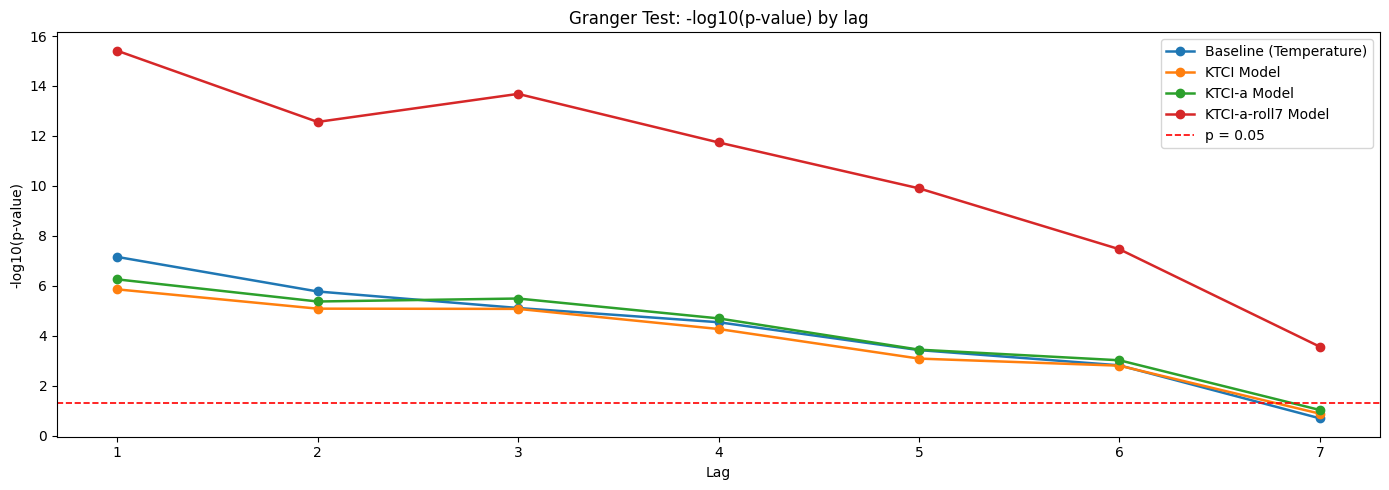

In [120]:
# ============================================================
# 5.3 Granger test: 과거 외생변수가 미래 방문객 수에 선행 정보를 주는가?
# ============================================================
GRANGER_MAX_LAG = 7

granger_rows = []
for model_name, x_col in MAIN_VARIABLES.items():
    pair_df = train_df[[TARGET_COL, x_col]].dropna().copy()
    if len(pair_df) <= GRANGER_MAX_LAG + 2:
        continue

    granger_result = grangercausalitytests(pair_df[[TARGET_COL, x_col]], maxlag=GRANGER_MAX_LAG, verbose=False)
    for lag, lag_result in granger_result.items():
        f_stat, p_value, _, _ = lag_result[0]["ssr_ftest"]
        granger_rows.append({
            "model": model_name,
            "predictor": x_col,
            "lag": lag,
            "f_stat": f_stat,
            "p_value": p_value,
        })

granger_df = pd.DataFrame(granger_rows)
display(granger_df.sort_values(["model", "lag"]).round(4))

granger_summary = (
    granger_df.sort_values(["model", "p_value", "lag"])
    .groupby("model", as_index=False)
    .first()
)
display(granger_summary[["model", "predictor", "lag", "f_stat", "p_value"]].round(4))

fig, ax = plt.subplots(figsize=(14, 5))
for model_name in MAIN_VARIABLES.keys():
    tmp = granger_df[granger_df["model"] == model_name].sort_values("lag")
    ax.plot(tmp["lag"], -np.log10(tmp["p_value"]), marker="o", linewidth=1.8, label=model_name)
ax.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1.2, label="p = 0.05")
ax.set_title("Granger Test: -log10(p-value) by lag")
ax.set_xlabel("Lag")
ax.set_ylabel("-log10(p-value)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## 5.2 SARIMAX 결과


In [121]:
# ============================================================
# 5.2 SARIMAX 모델 적합
# ============================================================
fitted_results = {}
predictions = {}
scores = []
model_features = {}

for model_name, main_var in MAIN_VARIABLES.items():
    result, pred, score, exog_cols = fit_sarimax_model(model_name, main_var, train_df, test_df, )
    fitted_results[model_name] = result
    predictions[model_name] = pred
    scores.append(score)
    model_features[model_name] = exog_cols

    print(f"=== {model_name} ===")
    print(f"main variable : {main_var}")
    print(f"n predictors  : {len(exog_cols)}")
    print(f"AIC           : {result.aic:,.1f}")
    print(f"BIC           : {result.bic:,.1f}")
    print(f"RMSE          : {score['RMSE']:,.2f}")
    print(f"MAE           : {score['MAE']:,.2f}")
    print(f"R²            : {score['R2']:.4f}")
    print(f"Adjusted R²   : {score['Adj_R2']:.4f}")
    print(f"event spec    : {score['no_event']}")
    print()


=== Baseline (Temperature) ===
main variable : tavg
n predictors  : 15
AIC           : 119,697.0
BIC           : 119,837.1
RMSE          : 13,315.24
MAE           : 8,848.34
R²            : 0.1787
Adjusted R²   : 0.1434


KeyError: 'no_event'

In [ ]:
# ============================================================
# 5.2 성능 비교
# ============================================================
score_df = pd.DataFrame(scores).sort_values(
    ["RMSE", "MAE", "Adj_R2"],
    ascending=[True, True, False]
)

score_df[["AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]] = (
    score_df[["AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]].round(3)
)

display(score_df[["model", "main_variable", "n_predictors", "AIC", "BIC", "RMSE", "MAE", "R2", "Adj_R2"]])

best_model = score_df.iloc[0]
print(f"Best model by test RMSE: {best_model['model']} ({best_model['main_variable']})")

score_df["model_short"] = score_df["model"].replace({
    "Baseline (Temperature)": "Baseline",
    "KTCI Model": "KTCI",
    "KTCI-a Model": "KTCI-a",
    "KTCI-a-roll7 Model": "KTCI-a-roll7",
})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

score_df.plot(x="model_short", y="RMSE", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
score_df.plot(x="model_short", y="MAE", kind="bar", ax=axes[1], legend=False, color="#F58518")
score_df.plot(x="model_short", y="R2", kind="bar", ax=axes[2], legend=False, color="#54A24B")
score_df.plot(x="model_short", y="Adj_R2", kind="bar", ax=axes[3], legend=False, color="#B279A2")

axes[0].set_title("Test RMSE")
axes[1].set_title("Test MAE")
axes[2].set_title("Test R²")
axes[3].set_title("Test Adjusted R²")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 5.2 잔차 진단: ACF/PACF + Ljung-Box
# ============================================================
residual_diagnostics = []
for model_name, result in fitted_results.items():
    resid = result.resid.dropna()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    plot_acf(resid, ax=axes[0], lags=30, title=f"Residual ACF: {model_name}")
    plot_pacf(resid, ax=axes[1], lags=30, title=f"Residual PACF: {model_name}", method="ywm")
    plt.tight_layout()
    plt.show()

    lb_df = acorr_ljungbox(resid, lags=[7, 14, 21], return_df=True)
    lb_df = lb_df.rename(columns={"lb_stat": "LB Stat", "lb_pvalue": "LB p-value"})
    lb_df["model"] = model_name
    residual_diagnostics.append(lb_df.reset_index().rename(columns={"index": "lag"}))

residual_diag_df = pd.concat(residual_diagnostics, ignore_index=True)
display(residual_diag_df.round(4))


In [ ]:
# ============================================================
# 5.2 Test 구간 실제값 vs 예측값
# ============================================================
plot_df = pd.DataFrame({"actual": test_df[TARGET_COL]})
for model_name, pred in predictions.items():
    plot_df[model_name] = pred

line_styles = {
    "actual": {"color": "black", "linewidth": 2.4, "linestyle": "-", "zorder": 8},
    "Baseline (Temperature)": {"color": "#4C78A8", "linewidth": 1.8, "linestyle": "--", "alpha": 0.95, "zorder": 2},
    "KTCI Model": {"color": "#F58518", "linewidth": 2.4, "linestyle": "-", "alpha": 1.0, "zorder": 7},
    "KTCI-a Model": {"color": "#54A24B", "linewidth": 1.8, "linestyle": "-.", "alpha": 0.95, "zorder": 4},
    "KTCI-a-roll7 Model": {"color": "#9D755D", "linewidth": 1.8, "linestyle": (0, (3, 1, 1, 1)), "alpha": 0.95, "zorder": 3},
}

fig, ax = plt.subplots(figsize=(17, 6))
plot_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
for model_name in MAIN_VARIABLES:
    plot_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])
ax.set_title("Test Period: Actual vs Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper left", frameon=True, ncol=2)
plt.tight_layout()
plt.show()

# KTCI 계열 세부 비교 + Baseline
fig, ax = plt.subplots(figsize=(17, 5))
plot_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
plot_df["Baseline (Temperature)"].plot(ax=ax, label="Baseline (Temperature)", **line_styles["Baseline (Temperature)"])
for model_name in ["KTCI Model", "KTCI-a Model", "KTCI-a-roll7 Model"]:
    plot_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])
ax.set_title("Test Period Focus: Baseline + KTCI Family Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Visitors")
ax.legend(loc="upper left", frameon=True, ncol=2)
plt.tight_layout()
plt.show()

# 환절기(월 기준 계절 != 기온 기준 계절) 구간만 확대 시각화
season_compare = df.loc[test_df.index, ["season_month", "season_temp"]].copy()
season_compare["is_transition"] = season_compare["season_month"] != season_compare["season_temp"]

if season_compare["is_transition"].any():
    transition_dates = season_compare.index[season_compare["is_transition"]]
    transition_blocks = []
    block_start = transition_dates[0]
    prev_date = transition_dates[0]

    for current_date in transition_dates[1:]:
        if (current_date - prev_date).days > 1:
            transition_blocks.append((block_start, prev_date))
            block_start = current_date
        prev_date = current_date
    transition_blocks.append((block_start, prev_date))

    context_days = 7
    fig, axes = plt.subplots(
        len(transition_blocks),
        1,
        figsize=(16, 4 * len(transition_blocks)),
        sharey=True,
    )
    if len(transition_blocks) == 1:
        axes = [axes]

    for ax, (start_date, end_date) in zip(axes, transition_blocks):
        window_start = start_date - pd.Timedelta(days=context_days)
        window_end = end_date + pd.Timedelta(days=context_days)
        window_df = plot_df.loc[(plot_df.index >= window_start) & (plot_df.index <= window_end)]

        window_df["actual"].plot(ax=ax, label="Actual", **line_styles["actual"])
        window_df["Baseline (Temperature)"].plot(ax=ax, label="Baseline (Temperature)", **line_styles["Baseline (Temperature)"])
        for model_name in ["KTCI Model", "KTCI-a Model", "KTCI-a-roll7 Model"]:
            window_df[model_name].plot(ax=ax, label=model_name, **line_styles[model_name])

        month_season = season_compare.loc[start_date, "season_month"]
        temp_season = season_compare.loc[start_date, "season_temp"]
        ax.axvspan(start_date, end_date, color="#F58518", alpha=0.14)
        ax.set_title(
            f"Transition Focus: Baseline + KTCI Family, {start_date.date()} ~ {end_date.date()} "
            f"(month={month_season}, temp={temp_season})"
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Visitors")
        ax.legend(loc="upper left", frameon=True, ncol=2)

    plt.tight_layout()
    plt.show()
else:
    print("Test 구간에는 month 기준 계절과 temperature 기준 계절이 다른 환절기 구간이 없습니다.")


In [ ]:
# ============================================================
# 5.2 주요 계수 비교
# ============================================================
coef_rows = []
for model_name, result in fitted_results.items():
    for term, coef, p_value in zip(result.params.index, result.params.values, result.pvalues.values):
        coef_rows.append({
            "model": model_name,
            "term": term,
            "coef": coef,
            "p_value": p_value,
        })

coef_df = pd.DataFrame(coef_rows)
important_terms = [
    *SCALAR_MAIN_VARS,
    "offdays_left",
    "long_break_3p",
    "pre_holiday",
    "rain_c_x_weekend",
    "rain_c_x_offdays_left",
    *[f"{var}_c_x_weekend" for var in SCALAR_MAIN_VARS],
    *[f"{var}_c_x_offdays_left" for var in SCALAR_MAIN_VARS],
    *COVID_COMPARE_COLS,
    *BASE_CONTROL_COLS,
]
display(
    coef_df[coef_df["term"].isin(important_terms)]
    .sort_values(["model", "p_value"])
    .reset_index(drop=True)
)


## 해석 안내
- 최종 비교는 `test RMSE`, `test MAE`, `test R²`를 우선 보세요.
- `AIC`와 `BIC`는 학습 구간 적합도 참고값으로만 보세요.
- 해석 순서는 `baseline` -> `ktci` -> `ktci-a` -> `ktci-a-roll7`입니다.
- `ktci-a`가 좋아지면, 월 기준 계정보다 한국의 실제 계절 전환을 반영한 정의가 더 설명력이 있다는 뜻으로 읽을 수 있습니다.
- 정상성은 시계열 그래프, ADF, KPSS, ACF, PACF로 확인합니다.
- Granger test는 외생변수가 방문객 수에 선행 정보를 주는지 보는 보조 근거입니다.
- 공적분은 이 프로젝트의 메인 근거가 아니고, 핵심 증거는 정상성, Granger 선별, 그리고 SARIMAX의 test 성능입니다.
